<a href="https://colab.research.google.com/github/GauriNair05/Image-Classification-using-Convolutional-Neural-Networks/blob/main/Binary_Classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
dog-and-cat-classification-dataset/
    PetImages/
        Dog/
            7981.jpg
            6234.jpg
            1269.jpg
        Cat/
            7981.jpg
            6234.jpg
            1269.jpg
Number of classes: 2
Classes: ['Dog', 'Cat']
Total number of images: 24998
Sample Image dimensions (Width, Height, Channels): (500, 375), RGB


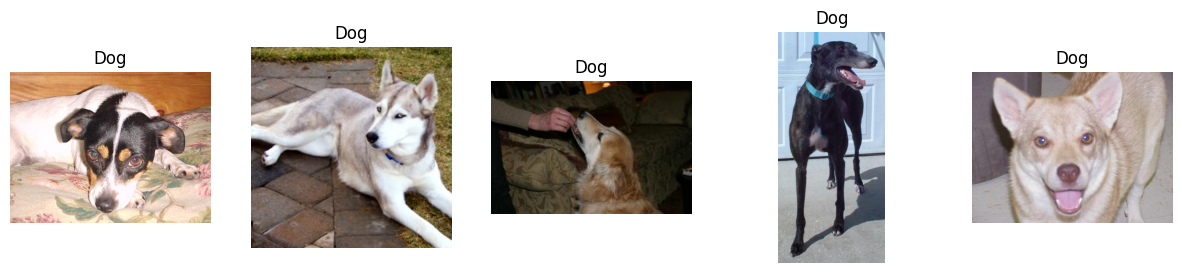

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Epoch 1/10
587/625 ━━━━━━━━━━━━━━━━━━━━ 24s 644ms/step - accuracy: 0.5949 - loss: 0.6691

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 436s 696ms/step - accuracy: 0.6659 - loss: 0.5982 - val_accuracy: 0.7581 - val_loss: 0.4967
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 433s 693ms/step - accuracy: 0.7784 - loss: 0.4627 - val_accuracy: 0.7867 - val_loss: 0.4575
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 439s 688ms/step - accuracy: 0.8248 - loss: 0.3917 - val_accuracy: 0.7941 - val_loss: 0.4257
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 429s 687ms/step - accuracy: 0.8544 - loss: 0.3300 - val_accuracy: 0.8257 - val_loss: 0.3794
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 461s 738ms/step - accuracy: 0.8870 - loss: 0.2666 - val_accuracy: 0.8359 - val_loss: 0.3814
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 454s 726ms/step - accuracy: 0.9189 - loss: 0.1981 - val_accuracy: 0.8347 - val_loss: 0.4272
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 439s 702ms/step - accuracy: 0.9456 - loss: 0.1396 - val_accuracy: 0.8277 - val_loss: 0.4423
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 446s 708ms/step - accuracy: 0.9645 - loss: 0.09

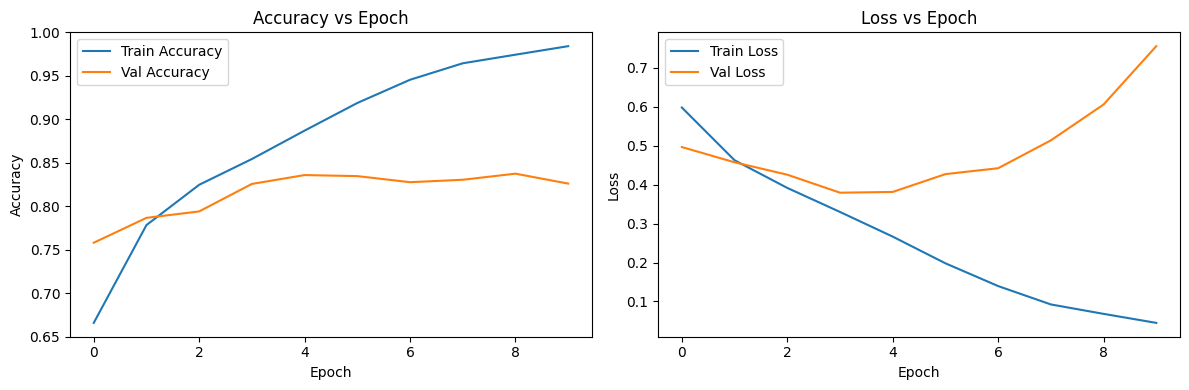

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import kagglehub

path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

target_dir = path
for root, dirs, files in os.walk(path):
    if any(d.lower() in ['cats', 'dogs', 'cat', 'dog'] for d in dirs):
        target_dir = root
        break

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]:
        print(f"{subindent}{f}")

image_paths = []
labels = []

for root, dirs, files in os.walk(target_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))
            labels.append(os.path.basename(root))

classes = list(set(labels))
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")
print(f"Total number of images: {len(image_paths)}")

if image_paths:
    with Image.open(image_paths[0]) as img:
        print(f"Sample Image dimensions (Width, Height, Channels): {img.size}, {img.mode}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(min(5, len(image_paths))):
    img = Image.open(image_paths[i])
    axes[i].imshow(img)
    axes[i].set_title(labels[i])
    axes[i].axis('off')
plt.show()

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

train_generator = datagen.flow_from_directory(
    target_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

test_generator = datagen.flow_from_directory(
    target_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).ravel()
y_true = test_generator.classes

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Test Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()